In [8]:
import numpy as np
import torchaudio
import speechbrain as sb
import os
# Load the pretrained ECAPA-TDNN model for speaker verification
from speechbrain.inference import SpeakerRecognition
from sklearn.metrics import roc_curve
from torch.nn.utils.rnn import pad_sequence

# Load the fine-tuned model
from speechbrain.pretrained import EncoderClassifier

import numpy as np
import torchaudio
import speechbrain as sb
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from speechbrain.inference import SpeakerRecognition
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torchaudio.transforms import MelSpectrogram, GriffinLim
import os
import torchaudio
import torch
from sklearn.model_selection import train_test_split
from speechbrain.pretrained import EncoderClassifier
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as transforms


/var/folders/2d/mf93wtk914vbrkclc8d3hrt40000gn/T/ipykernel_68387/2658283284.py:11: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderClassifier


Load the model and report size and number of paramters

In [25]:
model_dir = "pretrained_models/spkrec-ecapa"
teacher_model = SpeakerRecognition.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir=model_dir)

size_in_MB = sum(os.path.getsize(os.path.join(model_dir, f)) for f in os.listdir(model_dir)) / (1024 * 1024)
print(f"Model size: {size_in_MB:.2f} MB")


Model size: 84.86 MB


/Users/ghs6kor/miniconda3/envs/spkver310/lib/python3.10/site-packages/speechbrain/utils/checkpoints.py:194: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.

A smaller student model based on the architecture of the ECAPA-TDNN model. You can modify the number of layers or the size of each layer (e.g., reduce the number of TDNN blocks, lower the hidden dimension, etc.).

In [26]:


num_classes = 50


# Load the pre-trained ECAPA TDNN model
pretrained_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
pretrained_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)  # Adjusting output layer

# Load the fine-tuned model
fine_tuned_classifier = EncoderClassifier.from_hparams(source="speechbrain/spkrec-ecapa-voxceleb", savedir="pretrained_models/ecapa_tdnn")
fine_tuned_classifier.mods.classifier = torch.nn.Linear(in_features=192, out_features=num_classes)
fine_tuned_classifier.load_state_dict(torch.load("fine_tuned_ecapa_tdnn_200.pth"))

/var/folders/2d/mf93wtk914vbrkclc8d3hrt40000gn/T/ipykernel_28476/3614258192.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  fine_tuned_classifier.load_state_dict(torch.

<All keys matched successfully>

In [27]:
# Custom dataset class
class DigitUtterDataset(Dataset):
    
    def __init__(self, data_dir, type, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.audio_paths = []
        self.labels = []
        if type == "enroll":
            self.folder = "C"
        if type == "verify":
            self.folder = "D"
        self._prepare_data()


    def _prepare_data(self):
        # Assuming directory structure is `data_dir/speaker_id/session_x/audio.wav`
        speakers = sorted(os.listdir(self.data_dir))  # Sort speakers to assign consistent indices
        print(speakers)
        speakers.remove('.DS_Store')
        # Step 2: Create a mapping from speaker names to integer indices
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}
        # Optional: If you need just the indices in a set
        speakers_mod = set(speaker_to_index.values())
        #print(speakers_mod)
        
        speaker_to_index = {speaker: idx for idx, speaker in enumerate(speakers)}  # Map to indices
    
        for speaker in speakers:
            speaker_path = os.path.join(dataset_path, speaker)
            #print("Speaker Path",speaker_path)
            if os.path.isdir(speaker_path):
                for session in [self.folder]:  # Iterate over sessions
                    session_path = os.path.join(speaker_path, f"{speaker}{session}")
                    #print("Session Path", session_path)
                    if os.path.isdir(session_path):
                        #print(session_path)
                        for audio_file in os.listdir(session_path):
                            #print("Audio File Path ", audio_file)
                            # Check if the file is a .wav file
                            if audio_file.endswith('.wav'):
                                audio_path = os.path.join(session_path, audio_file)
                                self.audio_paths.append(audio_path)
                                #print(speaker_to_index[speaker])
                                self.labels.append(speaker_to_index[speaker])  # Use speaker ID as label 
                            else:
                                print("Not wave file")
                            # Check for duplicates
                                # if audio_path not in unique_samples:
                                #     unique_samples.add(audio_path)
                                #     self.audio_paths.append(audio_path)
                                #     self.labels.append(speaker)
                                # else:
                                #     print(f"Duplicate found: {audio_path}")
                    else:
                        print("This is not directory ->", session_path)   
    def __len__(self):
        return len(self.audio_paths)

    def __getitem__(self, idx):
        audio_path = self.audio_paths[idx]
        label = int(self.labels[idx])
        #print(f"Loading sample {idx}: {audio_path}, label: {label}")  # Debug statement

        audio, sample_rate = torchaudio.load(audio_path)  # Load audio file
        if self.transform:
            audio = self.transform(audio)
        return audio.squeeze(0), label  # Remove unnecessary channel dimension

    
# Custom collate function for padding
def collate_fn(batch):
    # Separate the batch into audio tensors and labels
    audios, labels = zip(*batch)

   # Calculate original lengths before padding
    lengths = torch.tensor([audio.shape[0] for audio in audios])

    # Pad all audio tensors to the length of the longest audio in the batch
    padded_audios = pad_sequence(audios, batch_first=True)  # Pads to [batch_size, max_len]

    labels = torch.tensor([int(label) for label in labels])

    return padded_audios, labels, lengths


In [22]:
# Generate enrollment embeddings
def generate_enrollment_embeddings(model, enrollment_loader):
    enrollment_embeddings = {}
    with torch.no_grad():
        for inputs, labels, _ in enrollment_loader:
            embeddings = model.encode_batch(inputs)
            for i, label in enumerate(labels):
                speaker_id = label.item()
                if speaker_id not in enrollment_embeddings:
                    enrollment_embeddings[speaker_id] = []
                enrollment_embeddings[speaker_id].append(embeddings[i].cpu().numpy())
    
    # Average embeddings for each speaker
    for speaker_id in enrollment_embeddings:
        enrollment_embeddings[speaker_id] = np.mean(enrollment_embeddings[speaker_id], axis=0)
    
    return enrollment_embeddings

In [23]:
dataset_path = 'DigitUtter-IITDH-dataset-master' 
enroll_dataset = DigitUtterDataset(dataset_path, type="enroll")
enrollment_loader = DataLoader(enroll_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
enrollment_embeddings = generate_enrollment_embeddings(fine_tuned_classifier, enrollment_loader)
print("Enrollment embeddings completed, " + str(len(enrollment_embeddings)))

['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


NameError: name 'fine_tuned_classifier' is not defined

In [30]:
from sklearn.metrics import roc_curve
import numpy as np
import torch
import torch.nn.functional as F

# Assuming `model`, `verification_loader`, and `enrollment_embeddings` are defined and ready

def generate_verification_scores(model, verification_loader, enrollment_embeddings):
    scores = []
    labels = []
    with torch.no_grad():
        for inputs, labels_batch, _ in verification_loader:
            verification_embeddings = model.encode_batch(inputs)
            for i, label in enumerate(labels_batch):
                speaker_id = label.item()
                # print("Comapring =====>")
                # print(torch.tensor(enrollment_embeddings[speaker_id]))
                # print("WITH  =====>")
                #print(verification_embeddings[i])
                # Positive pair (same speaker)
                if speaker_id in enrollment_embeddings:
                    score = F.cosine_similarity(
                        torch.tensor(enrollment_embeddings[speaker_id]).squeeze(),
                        verification_embeddings[i].squeeze(),
                        dim=0
                    )
                    #print("SCORE", score)
                    scores.append(score)
                    labels.append(1)  # Positive (same speaker)

                # Negative pair (different speaker)
                other_speaker_id = np.random.choice([id for id in enrollment_embeddings.keys() if id != speaker_id])
                score = F.cosine_similarity(
                    torch.tensor(enrollment_embeddings[other_speaker_id]).squeeze(),
                    verification_embeddings[i].squeeze(),
                    dim=0
                )
                scores.append(score)
                labels.append(0)  # Negative (different speaker)
    
    return scores, labels

In [31]:
# Generate enrollment and verification embeddings
verify_dataset = DigitUtterDataset(dataset_path, type="verify")
verify_loader = DataLoader(verify_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
scores_fine_tuned, labels_finetuned = generate_verification_scores(fine_tuned_classifier, verify_loader, enrollment_embeddings)


['.DS_Store', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050']


In [32]:
scores_pre_trained, labels_pre_trained = generate_verification_scores(pretrained_classifier, verify_loader, enrollment_embeddings)

In [33]:
# Calculate EER
def calculate_eer(scores, labels):
    scores = np.array(scores)
    labels = np.array(labels)

    if len(set(labels)) < 2:
        raise ValueError("Labels must contain at least two classes for EER calculation.")
        
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr

    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    
    return eer, eer_threshold

In [34]:
# Calculate EER
eer, eer_threshold = calculate_eer(scores_pre_trained, labels_pre_trained)
print(f"Pre trained EER: {eer * 100:.2f}% at threshold: {eer_threshold:.4f}")
eer, eer_threshold = calculate_eer(scores_fine_tuned, labels_finetuned)
print(f"Fine Tuned EER: {eer * 100:.2f}% at threshold: {eer_threshold:.4f}")

Pre trained EER: 24.75% at threshold: 0.0602
Fine Tuned EER: 16.57% at threshold: 0.0968


In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def plot_eer(scores, labels, str=None):
    # Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1 - tpr  # False Negative Rate (FNR) is 1 - TPR

    # Find the Equal Error Rate (EER)
    eer_threshold = thresholds[np.nanargmin(np.abs(fnr - fpr))]
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]

    # Plot FAR, FRR, and the EER point
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, fpr, label="False Acceptance Rate (FAR)", color="blue")
    plt.plot(thresholds, fnr, label="False Rejection Rate (FRR)", color="red")
    plt.axvline(eer_threshold, color="green", linestyle="--", label=f"EER Threshold: {eer_threshold:.2f}")
    plt.scatter(eer_threshold, eer, color="purple", s=100, zorder=5, label=f"EER: {eer * 100:.2f}%")
    plt.xlabel("Threshold")
    plt.ylabel("Error Rate")
    plt.title("Equal Error Rate (EER) Curve for " + str)
    plt.legend()
    plt.grid(True)
    plt.show()


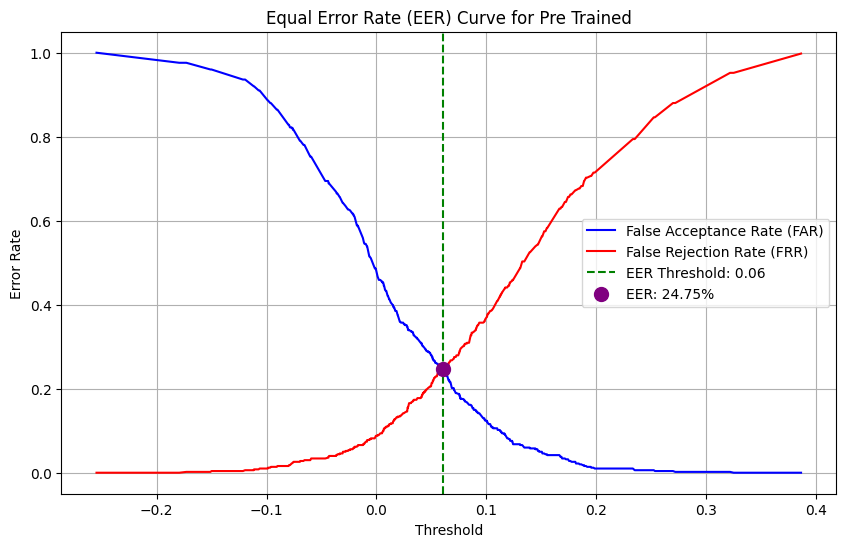

In [36]:
# Call the plot function with the generated scores and labels
plot_eer(scores_pre_trained, labels_pre_trained, str = "Pre Trained")

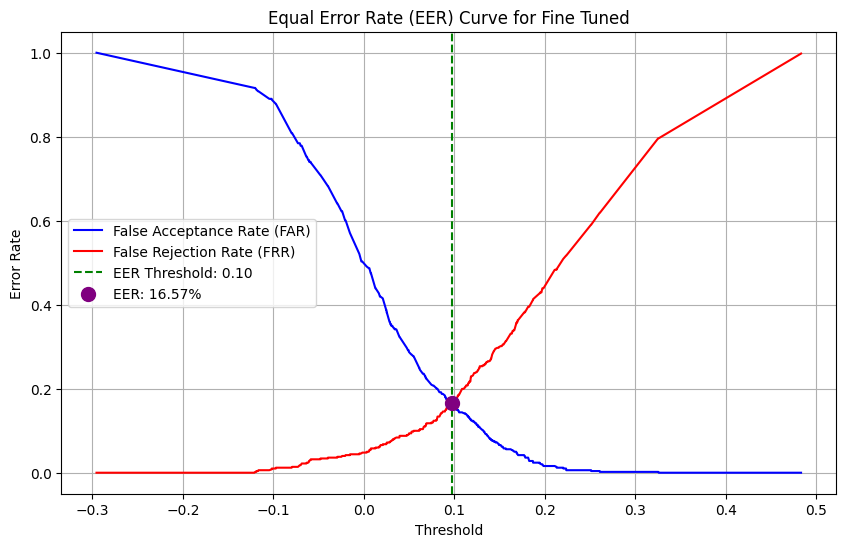

In [37]:
# Call the plot function with the generated scores and labels
plot_eer(scores_fine_tuned, labels_finetuned, str = "Fine Tuned")